# Modeling and Analysis on First Phishing URL Dataset
Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.model_selection import GridSearchCV

In [ ]:
Phishing_Data = pd.read_csv('/content/dataset_phishing.csv')
Phishing_Data.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [ ]:
X = Phishing_Data.drop(["url","status"],axis =1)
y = Phishing_Data["status"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
lr_model  = LogisticRegression()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model.fit(X_train_scaled,y_train)
y_pred = lr_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.9558180227471567

In [ ]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

  legitimate       0.95      0.96      0.96      1157
    phishing       0.96      0.95      0.96      1129

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



In [ ]:
kf = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(lr_model,X_train_scaled,y_train,cv=kf)
print(scores.mean())


0.9424763684523475


All the metrics are very good. They are in the mid - high 90 percent range. Let's do hyperparameter tuning to see if we can improve them any further.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
logistic_regression = LogisticRegression()
param_grid = {
    'C': [0.01, 0.1, 1, 10,100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'],            # Regularization type (L1 or L2)
    'solver': ['liblinear', 'saga']     # Solvers that support both L1 and L2
}
grid_search = GridSearchCV(estimator=logistic_regression,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1,
                           n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test_scaled, y_test)
print(f"Test set accuracy with best model: {test_accuracy:.4f}")
y_pred = best_model.predict(X_test_scaled)
report = classification_report(y_test,y_pred)
print(report)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score: 0.9426
Test set accuracy with best model: 0.9576
              precision    recall  f1-score   support

  legitimate       0.96      0.96      0.96      1157
    phishing       0.96      0.95      0.96      1129

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



A very slight improvement in test and cross validation accuracy is evident. Let's do KNN Classifier now.

In [ ]:
KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train_scaled,y_train)
y_pred = KNN_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9444444444444444


In [ ]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

  legitimate       0.93      0.96      0.95      1157
    phishing       0.96      0.92      0.94      1129

    accuracy                           0.94      2286
   macro avg       0.95      0.94      0.94      2286
weighted avg       0.95      0.94      0.94      2286



In [ ]:
scores = cross_val_score(KNN_model,X_train_scaled,y_train,cv=kf)
print(scores.mean())

0.9339450238259598


Metrics are really good but not as good as Logistic Regression. Test and cross validation accuracy are in the low to mid-90 percent range (approximately 94%). The phishing f1 score is high but slightly lower than the legitimate f1 score. Let's do hyperparameter tuning now.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
knn = KNeighborsClassifier()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'n_neighbors':np.arange(2,11),  # Number of neighbors (k)
    'p': [1, 2], # Value for minkowski metric
    'weights': ['uniform', 'distance']
}
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)


print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


best_knn = grid_search.best_estimator_


y_pred = best_knn.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the best KNN model on the test set: {accuracy:.4f}")

report = classification_report(y_test,y_pred)
print(report)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.94007008 0.91819782 0.92891471        nan 0.94881875
 0.93689871 0.938867          nan 0.94914704 0.92705577 0.93941351
        nan 0.95133403 0.93394502 0.93842883        nan 0.9510061
 0.92814945 0.93919415        nan 0.95209995 0.93230484 0.93766368
        nan 0.95199084 0.92705583 0.93689811        nan 0.95264706
 0.93011768 0.93580438        nan 0.95199066 0.92530583 0.93580444]
  warnings.warn(


Best parameters: {'n_neighbors': np.int64(9), 'p': 1, 'weights': 'distance'}
Best cross-validation score: 0.9526
Accuracy of the best KNN model on the test set: 0.9598
              precision    recall  f1-score   support

  legitimate       0.95      0.97      0.96      1157
    phishing       0.97      0.95      0.96      1129

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



There is some improvement in all metrics. Now the test and cross validation accuracy scores are in the higher 90 percent range (approx. 95% and 96% respectively) and the f1 score for phishing urls is equal to that of legitimate urls. Let's do Bernoulli Naive Bayes now.

In [ ]:
Bernoulli_model = BernoulliNB()
Bernoulli_model.fit(X_train,y_train)
y_pred = Bernoulli_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.8801399825021873


In [ ]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

  legitimate       0.87      0.90      0.88      1157
    phishing       0.89      0.86      0.88      1129

    accuracy                           0.88      2286
   macro avg       0.88      0.88      0.88      2286
weighted avg       0.88      0.88      0.88      2286



In [ ]:
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(Bernoulli_model, X_train, y_train, cv=kf, scoring='accuracy')
scores.mean()

np.float64(0.8798123593502686)

Results are not bad but markedly worse than that of previous models. Test and cross validation accuracy are approximately 88%. The f1 score for phishing URLs is 88%, exactly equal to that of legitimate URLs. Let's do hyperparameter tuning now.  

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics  import accuracy_score, classification_report
bnb = BernoulliNB()
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'fit_prior': [True, False] # Whether to learn class prior probabilities or assume uniform
}
grid_search = GridSearchCV(
    estimator=bnb,
    param_grid=param_grid,
    scoring='accuracy', # Metric to optimize (e.g., accuracy, f1, recall, etc.)
    cv=5,
    verbose=1,
    n_jobs=-1 # Use all available CPU cores
)
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)
print("Grid Search complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.3f}")
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy of the best model: {test_accuracy:.3f}")
report = classification_report(y_test,y_pred)
print(report)

Starting Grid Search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Grid Search complete.
Best parameters found: {'alpha': 0.01, 'fit_prior': True}
Best cross-validation accuracy: 0.881
Test accuracy of the best model: 0.880
              precision    recall  f1-score   support

  legitimate       0.87      0.90      0.88      1157
    phishing       0.89      0.86      0.88      1129

    accuracy                           0.88      2286
   macro avg       0.88      0.88      0.88      2286
weighted avg       0.88      0.88      0.88      2286



Some improvement in cross validation but largely the same results as above. Let's do Decision Tree now.

In [ ]:
X = Phishing_Data.drop(["url","status"],axis =1)
y = Phishing_Data["status"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train,y_train)
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.931758530183727


In [ ]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

  legitimate       0.93      0.93      0.93      1157
    phishing       0.93      0.93      0.93      1129

    accuracy                           0.93      2286
   macro avg       0.93      0.93      0.93      2286
weighted avg       0.93      0.93      0.93      2286



In [ ]:
kf = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(dt_model,X_train,y_train,cv=kf)
print(scores.mean())

0.9336173944461527


The metrics are all in the lower 90 percent range (approximately 93%), worse than the other models. Let's do hyperparameter tuning now.

In [ ]:
from sklearn.model_selection import GridSearchCV
import numpy as np
model = DecisionTreeClassifier()
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': np.arange(3, 15)

}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print(f"Best parameters: {grid_search.best_params_}")

# Print the best score achieved
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Get the best estimator (the Decision Tree model with the optimal hyperparameters)
best_dtree = grid_search.best_estimator_

# Evaluate the best model on the test set
test_accuracy = best_dtree.score(X_test, y_test)
print(f"Test set accuracy with best estimator: {test_accuracy:.4f}")

y_pred = best_dtree.predict(X_test)
report = classification_report(y_test,y_pred)
print(report)

Best parameters: {'criterion': 'gini', 'max_depth': np.int64(10)}
Best cross-validation score: 0.9401
Test set accuracy with best estimator: 0.9339
              precision    recall  f1-score   support

  legitimate       0.93      0.94      0.94      1157
    phishing       0.94      0.93      0.93      1129

    accuracy                           0.93      2286
   macro avg       0.93      0.93      0.93      2286
weighted avg       0.93      0.93      0.93      2286



There is some improvement in accuracy score but now the legitimate f1 score (94%) is slightly higher than the phishing f1 score (93%). Let's try Random Forest now.  

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train,y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)


0.9702537182852143


In [ ]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

  legitimate       0.97      0.98      0.97      1157
    phishing       0.97      0.96      0.97      1129

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286



In [ ]:
k_folds = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_model, X_train, y_train, cv=k_folds, scoring='accuracy')
scores.mean()

np.float64(0.9648950234072258)

Results are the best so far. The test and cross validation accuracy rates are in the high 90 percent range. The f1 score for both phishing and legitimate classes is as well. Let's do hyperparameter tuning.  

In [ ]:
from sklearn.model_selection import GridSearchCV
model = RandomForestClassifier()
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20],      # Maximum depth of the tree
    'bootstrap': [True, False]        # Whether bootstrap samples are used when building trees
}
grid_search = GridSearchCV(estimator= model,
                           param_grid=param_grid,
                           cv=5,                 # Number of cross-validation folds
                           n_jobs=-1,            # Use all available CPU cores
                           verbose=2,            # Display progress messages
                           scoring='accuracy')   # Metric to optimize

grid_search.fit(X_train, y_train)

print("Best parameters found by Grid Search:")
print(grid_search.best_params_)

print("\nBest cross-validation score:")
print(grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
test_accuracy = best_rf_model.score(X_test, y_test)
print(f"\nAccuracy of the best model on the test set: {test_accuracy:.4f}")
y_pred = best_rf_model.predict(X_test)
report = classification_report(y_test,y_pred)
print(report)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found by Grid Search:
{'bootstrap': False, 'max_depth': None, 'n_estimators': 100}

Best cross-validation score:
0.9660980459482709

Accuracy of the best model on the test set: 0.9681
              precision    recall  f1-score   support

  legitimate       0.96      0.98      0.97      1157
    phishing       0.97      0.96      0.97      1129

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286



No real improvement. But results were already pretty good anyways. Let's tabulate the results.

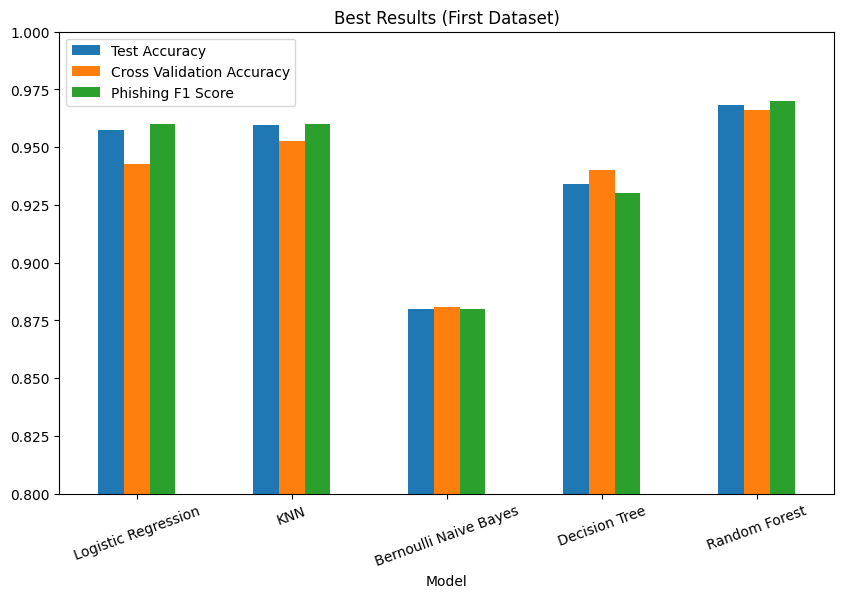

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
Table = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Bernoulli Naive Bayes','Decision Tree','Random Forest'],
    'Test Accuracy' : [0.9576,0.9598,0.880,0.9339, 0.9681],
    'Cross Validation Accuracy' : [0.9426,0.9526,0.881,0.9401, 0.9660980459482709],
    'Phishing F1 Score': [0.96,0.96,0.88,0.93,0.97]
})
Table.set_index('Model',inplace=True)
ax = Table.plot(kind="bar", figsize=(10,6))
plt.title("Best Results (First Dataset)")
plt.ylim(0.80, 1.0)
plt.xticks(rotation=20)
plt.show()